In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

store = pd.read_csv('../data/superstore_cleaned.csv')

In [2]:
# Color palette for the regions
palette = {
    'East': '#4CAF50',
    'West': '#2196F3',
    'Central': '#FFC107',
    'South': '#F44336'
}

In [3]:
unique_products = store['Product Name'].nunique()

print(f"Unique Products Sold: {unique_products}")

Unique Products Sold: 1850


In [ ]:
top_performing_products = (store.groupby('Product Name')['Quantity'].sum().sort_values(ascending=False).head(10))

print(top_performing_products)

Product Name
Staples                                                       215
Staple envelope                                               170
Easy-staple paper                                             150
Staples in misc. colors                                        86
KI Adjustable-Height Table                                     74
Storex Dura Pro Binders                                        71
Avery Non-Stick Binders                                        71
GBC Premium Transparent Covers with Diagonal Lined Pattern     67
Situations Contoured Folding Chairs, 4/Set                     64
Staple-based wall hangings                                     62
Name: Quantity, dtype: int64


In [5]:
lowest_performing_products = (store.groupby('Product Name')['Quantity'].sum().sort_values(ascending=True).head(10))

print(lowest_performing_products)

Product Name
Penpower WorldCard Pro Card Scanner                                          1
Global Enterprise Series Seating Low-Back Swivel/Tilt Chairs                 1
Bush Saratoga Collection 5-Shelf Bookcase, Hanover Cherry, *Special Order    1
Boston 1900 Electric Pencil Sharpener                                        1
Xerox 20                                                                     1
Grip Seal Envelopes                                                          2
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac             2
Xerox 1984                                                                   2
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                           2
PNY Rapid USB Car Charger - Black                                            2
Name: Quantity, dtype: int64


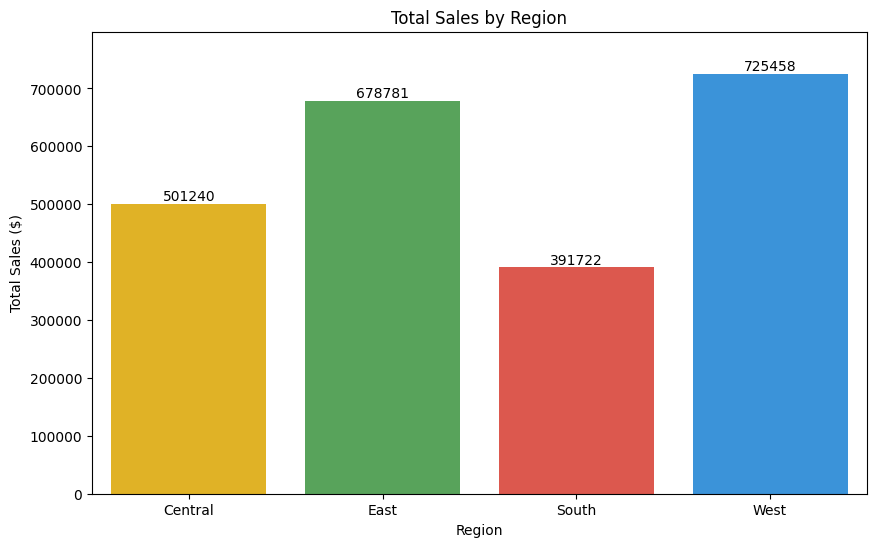

In [6]:
#Graph 1 - Assessment of overall sales 

region_sales = store.groupby('Region')['Sales'].sum().reset_index()
region_sales = region_sales.sort_values(by='Region', ascending=True)

plt.figure(figsize=(10,6))

ax = sns.barplot(data=region_sales, x='Region', y='Sales', hue='Region', palette=palette)

plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.ylim(0, region_sales['Sales'].max() * 1.1)

plt.show()

Highest: Western region with a value of 725485. 
Lowest: Southern region with a value of 391733.

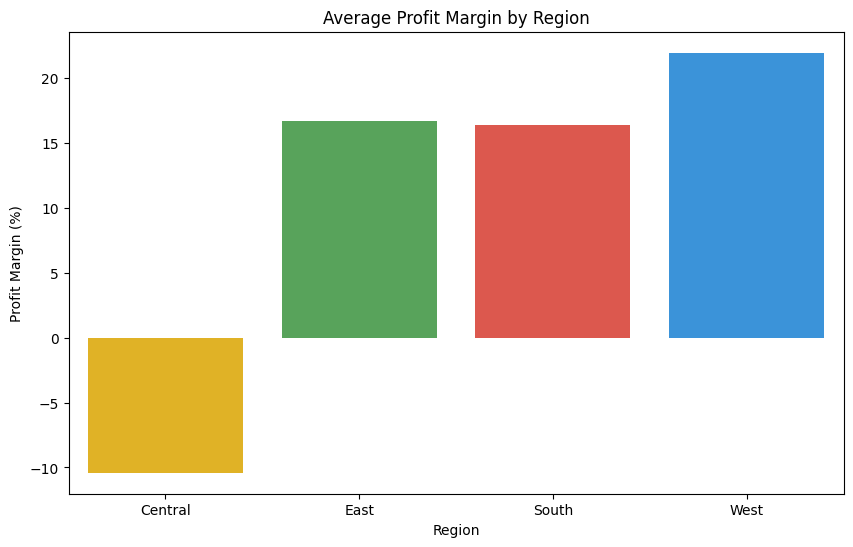

In [7]:
#Graph 2 - Assessment of Profit Margin by Region

store['Profit Margin %'] = (store['Profit'] / store['Sales']) * 100

# Aggregate
region_margin = store.groupby('Region')['Profit Margin %'].mean().reset_index()
region_margin = region_margin.sort_values(by='Region', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=region_margin, x='Region', y='Profit Margin %', hue='Region', palette=palette)

plt.title('Average Profit Margin by Region')
plt.xlabel('Region')
plt.ylabel('Profit Margin (%)')

plt.show()

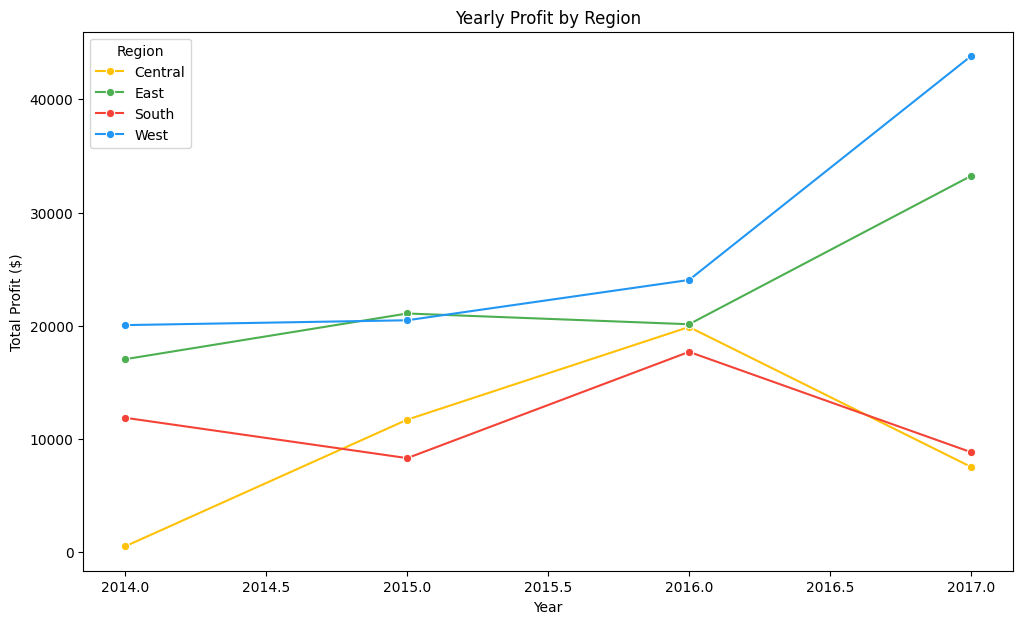

In [8]:
#Graph 3 - Region profitbaility over time 

store['Order Date'] = pd.to_datetime(store['Order Date'])
store['Year'] = store['Order Date'].dt.year
yearly_profit = store.groupby(['Year', 'Region'])['Profit'].sum().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(data=yearly_profit, x='Year', y='Profit', hue='Region', marker='o', palette=palette)
plt.title('Yearly Profit by Region')
plt.xlabel('Year')
plt.ylabel('Total Profit ($)')
plt.legend(title='Region')
plt.show()


Year 2014-2015: Central was the only one that performed well, with an increase in profit.
Year 2015-2016: Central and South performed well, while West and East perfomed ok.
Year 2016-2017: Futher investigates need to identify the cause of declining profit in Central and South, could possibly be high discount rate. Whereas, East and West performed well.

Need to compare each regional perfomance per year to find the root cause.

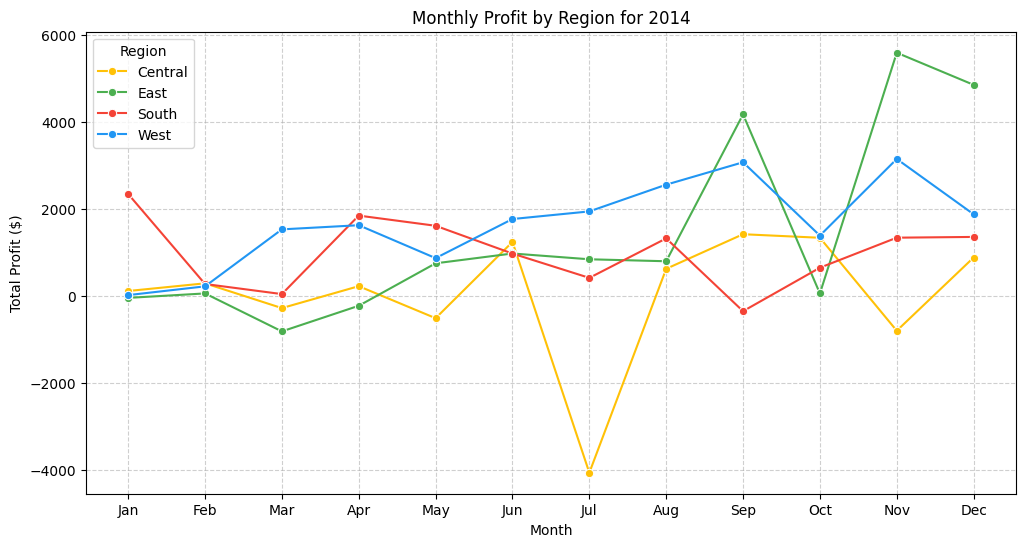

In [9]:
store['Order Date'] = pd.to_datetime(store['Order Date'])
store_2014 = store[store['Order Date'].dt.year == 2014].copy()
store_2014['Year'] = store_2014['Order Date'].dt.year
store_2014['Month'] = store_2014['Order Date'].dt.month
monthly_profit_2014 = store_2014.groupby(['Year', 'Month', 'Region'])['Profit'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_profit_2014, x='Month', y='Profit', hue='Region', marker='o', palette=palette)
plt.grid(True, linestyle='--', alpha=0.6, zorder=0)
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Monthly Profit by Region for 2014')
plt.xlabel('Month')
plt.ylabel('Total Profit ($)')
plt.legend(title='Region')
plt.show()


In [10]:
# Verify start and end dates
start_date = store['Order Date'].min()
end_date = store['Order Date'].max()

print(f"Start Date: {start_date}")
print(f"End Date: {end_date}")
print(f"Duration: {end_date - start_date}")

Start Date: 2014-01-03 00:00:00
End Date: 2017-12-30 00:00:00
Duration: 1457 days 00:00:00


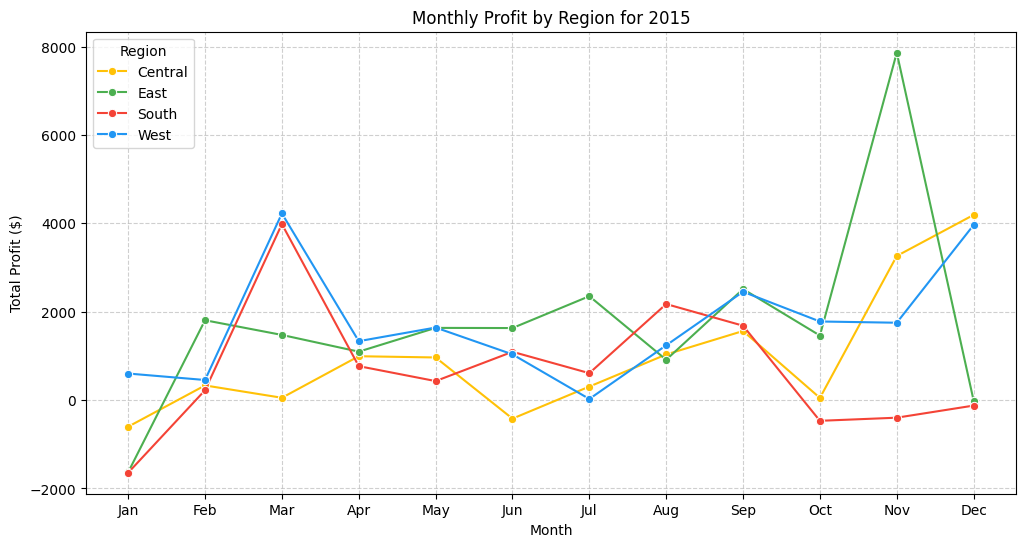

In [11]:
store['Order Date'] = pd.to_datetime(store['Order Date'])
store_2015 = store[store['Order Date'].dt.year == 2015].copy()
store_2015['Year'] = store_2015['Order Date'].dt.year
store_2015['Month'] = store_2015['Order Date'].dt.month
monthly_profit_2015 = store_2015.groupby(['Year', 'Month', 'Region'])['Profit'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_profit_2015, x='Month', y='Profit', hue='Region', marker='o', palette=palette)
plt.grid(True, linestyle='--', alpha=0.6, zorder=0)
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Monthly Profit by Region for 2015')
plt.xlabel('Month')
plt.ylabel('Total Profit ($)')
plt.legend(title='Region')
plt.show()


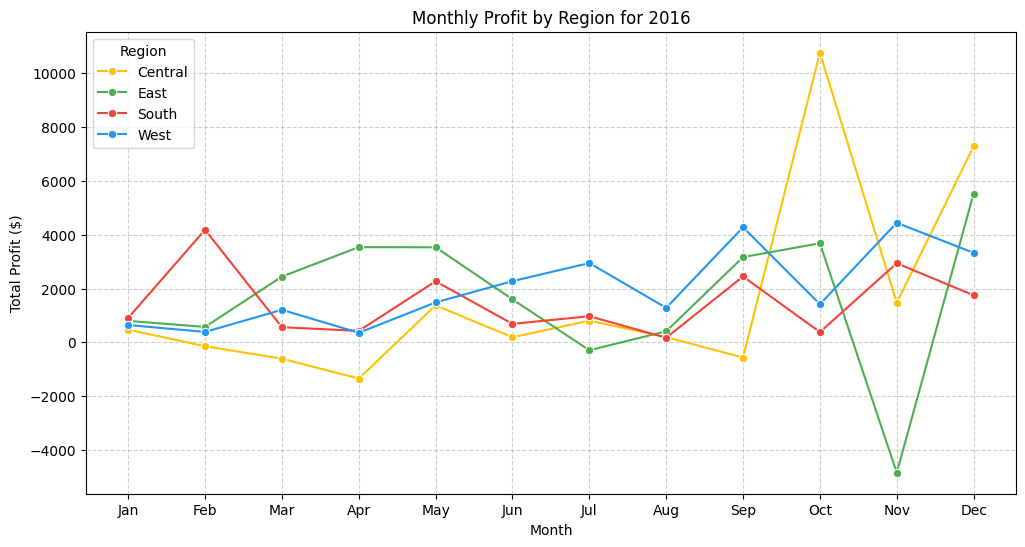

In [12]:
store['Order Date'] = pd.to_datetime(store['Order Date'])
store_2016 = store[store['Order Date'].dt.year == 2016].copy()
store_2016['Year'] = store_2016['Order Date'].dt.year
store_2016['Month'] = store_2016['Order Date'].dt.month
monthly_profit_2016 = store_2016.groupby(['Year', 'Month', 'Region'])['Profit'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_profit_2016, x='Month', y='Profit', hue='Region', marker='o', palette=palette)
plt.grid(True, linestyle='--', alpha=0.6, zorder=0)
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Monthly Profit by Region for 2016')
plt.xlabel('Month')
plt.ylabel('Total Profit ($)')
plt.legend(title='Region')
plt.show()


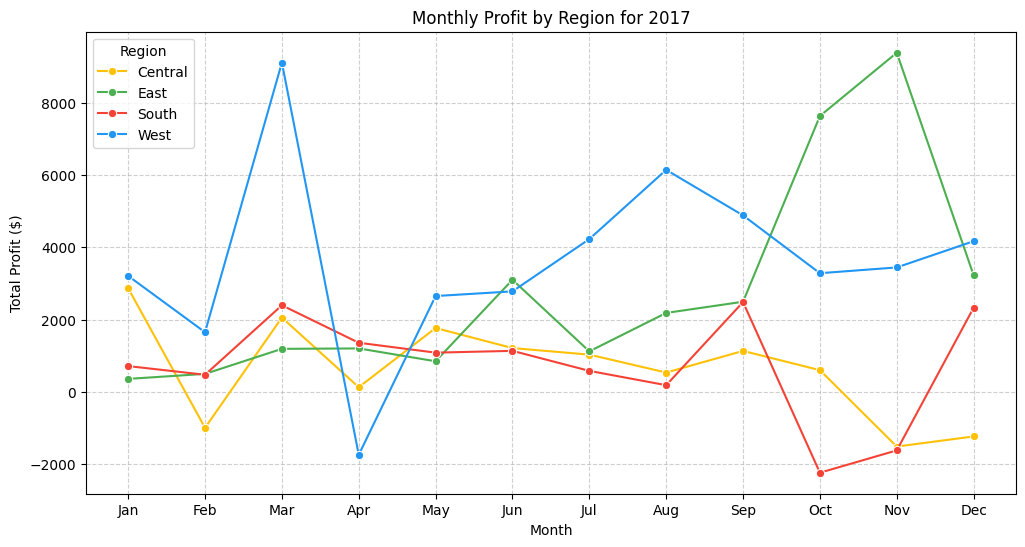

In [13]:
store['Order Date'] = pd.to_datetime(store['Order Date'])
store_2017 = store[store['Order Date'].dt.year == 2017].copy()
store_2017['Year'] = store_2017['Order Date'].dt.year
store_2017['Month'] = store_2017['Order Date'].dt.month
monthly_profit_2017 = store_2017.groupby(['Year', 'Month', 'Region'])['Profit'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_profit_2017, x='Month', y='Profit', hue='Region', marker='o', palette=palette)
plt.grid(True, linestyle='--', alpha=0.6, zorder=0)
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Monthly Profit by Region for 2017')
plt.xlabel('Month')
plt.ylabel('Total Profit ($)')
plt.legend(title='Region')
plt.show()


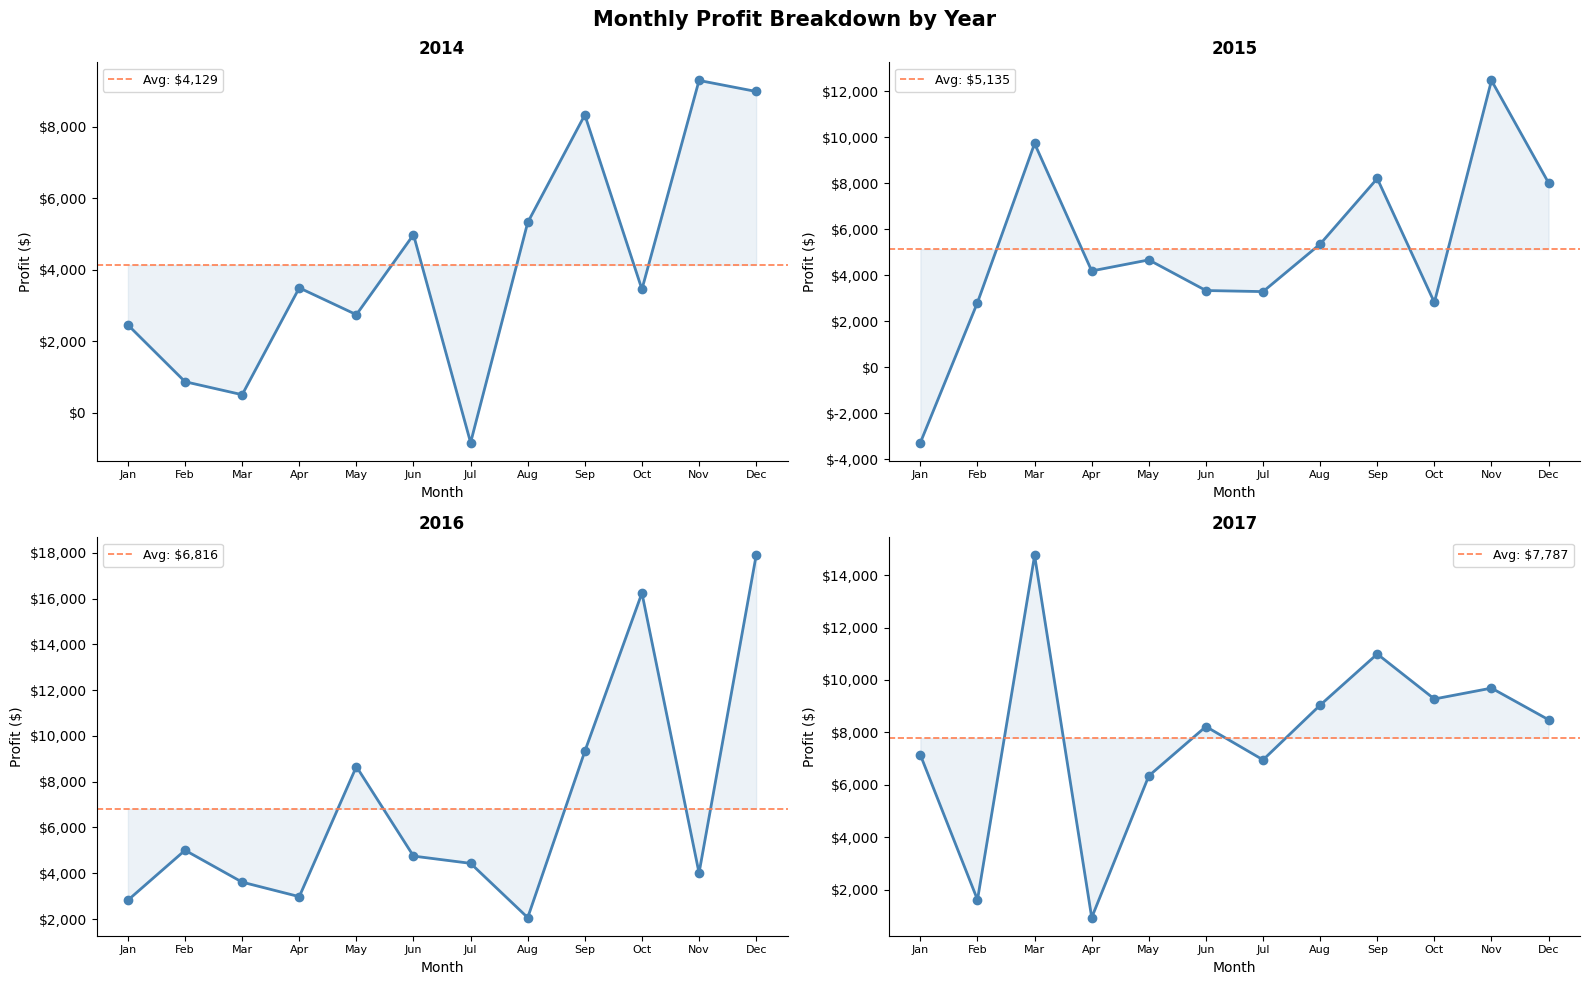

In [14]:
from matplotlib import ticker as mticker

# Monthly profit by year to see where spikes occur 
monthly_profit = (store.groupby(['Order Year', 'Order Month'])['Profit'].sum().reset_index())

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Monthly Profit Breakdown by Year', fontsize=15, fontweight='bold')

for idx, year in enumerate(sorted(monthly_profit['Order Year'].unique())):
    ax = axes[idx // 2][idx % 2]
    data = monthly_profit[monthly_profit['Order Year'] == year]

    ax.plot(data['Order Month'], data['Profit'], marker='o', linewidth=2, color='steelblue')
    ax.axhline(y=data['Profit'].mean(), color='coral', linestyle='--', linewidth=1.2, label=f"Avg: ${data['Profit'].mean():,.0f}")
    ax.fill_between(data['Order Month'], data['Profit'], data['Profit'].mean(), alpha=0.1, color='steelblue')

    ax.set_title(f"{year}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Profit ($)')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()


- Although the monthly profit ($) is volatile, we can notice a trend throughout the year. It increases and decreases around a specific time of the year. 
- This suggests event-driven discounting or seasonal demand patterns rather than a structural business problem. Need to further investigation on product category sales.

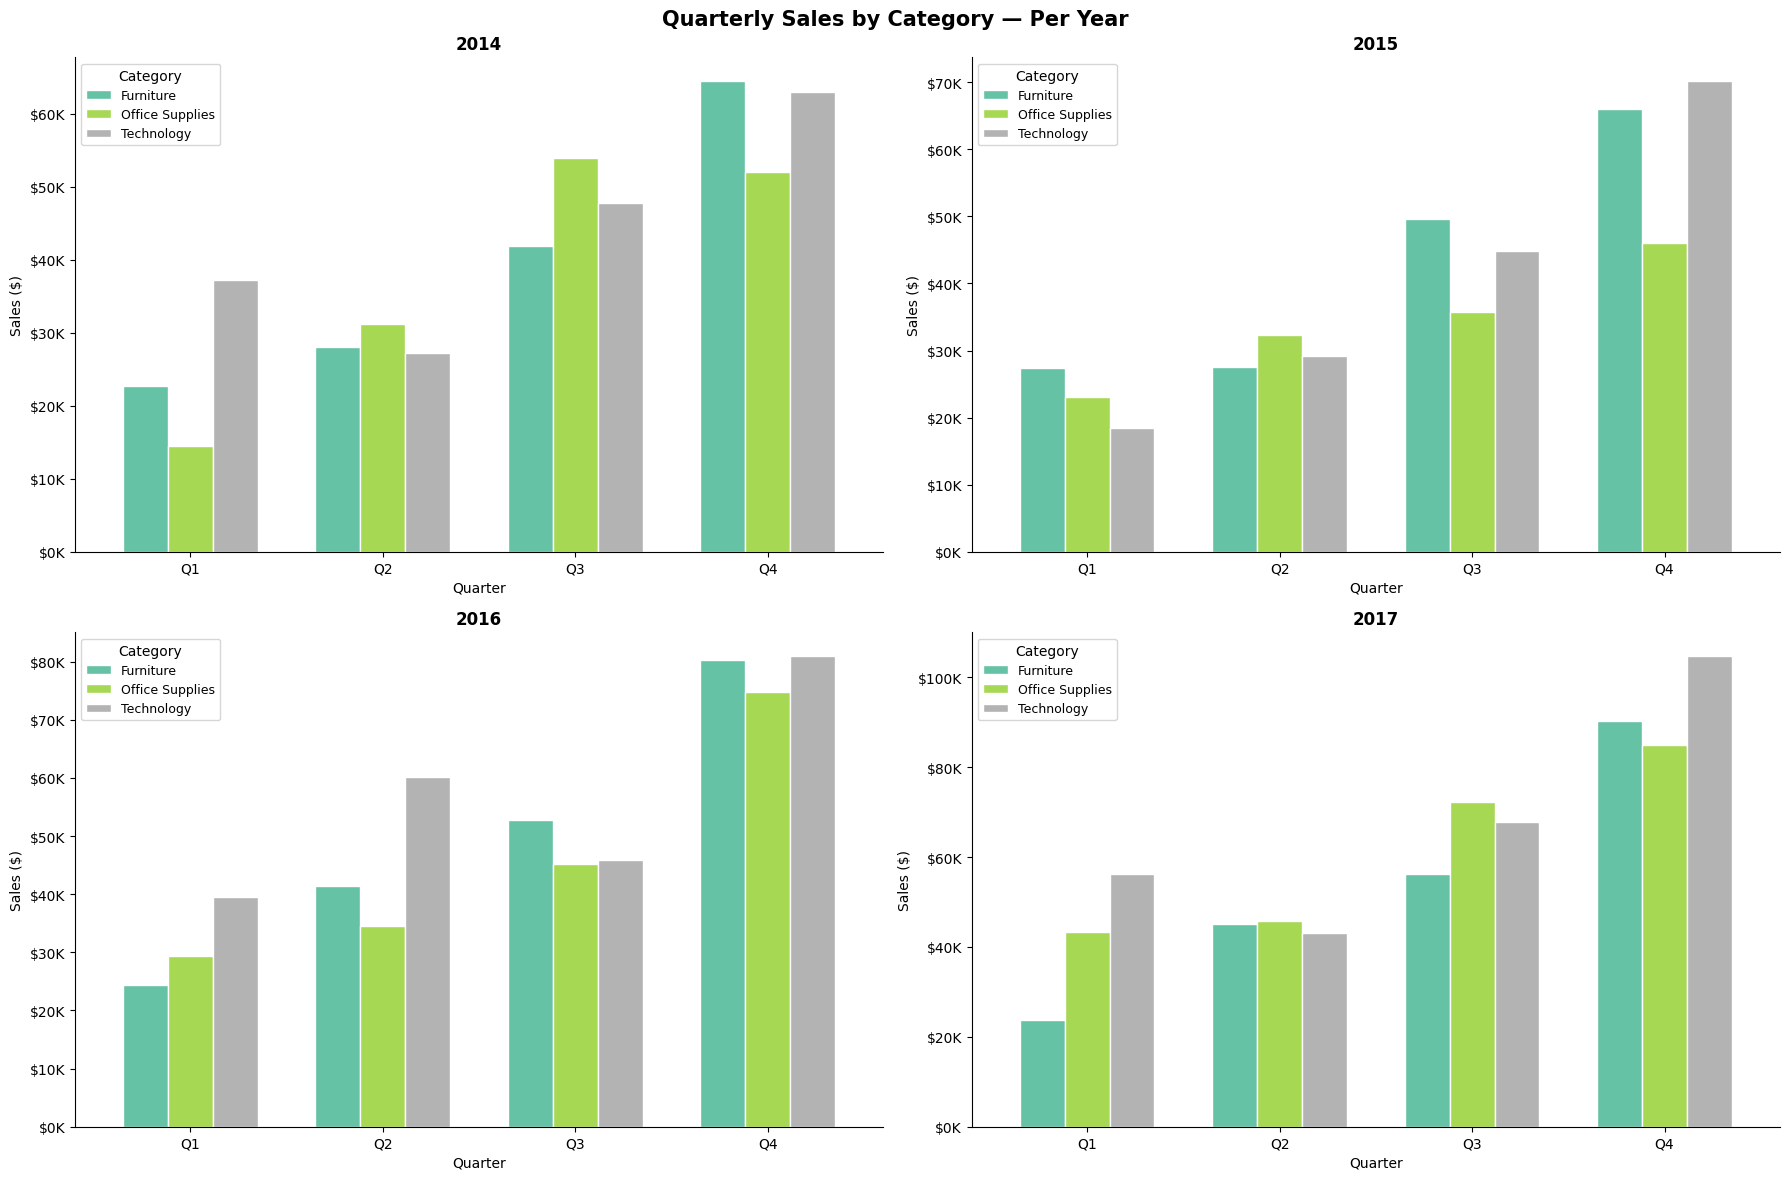

In [15]:
# Quarterly Sales by Category
store['Order Quarter'] = store['Order Date'].dt.quarter

quarterly_category = (store.groupby(['Order Year', 'Order Quarter', 'Category'])['Sales'] .sum() .reset_index())

quarterly_category['Year_Quarter'] = ('Q' + quarterly_category['Order Quarter'].astype(str) +' ' + quarterly_category['Order Year'].astype(str))

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Quarterly Sales by Category — Per Year', fontsize=15, fontweight='bold')

for idx, year in enumerate(sorted(quarterly_category['Order Year'].unique())):
    ax = axes[idx // 2][idx % 2]
    data = quarterly_category[quarterly_category['Order Year'] == year]
    pivot = data.pivot(index='Order Quarter', columns='Category', values='Sales').fillna(0)

    pivot.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', width=0.7)

    ax.set_title(f"{year}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Quarter')
    ax.set_ylabel('Sales ($)')
    ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'], rotation=0)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1000:.0f}K"))
    ax.legend(title='Category', fontsize=9)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()



- We can observe that Q1 is when the weakest sales performance occurs, relative to the other quaters.
- Q4 has the highest sales performance, compared the the other quaters. 

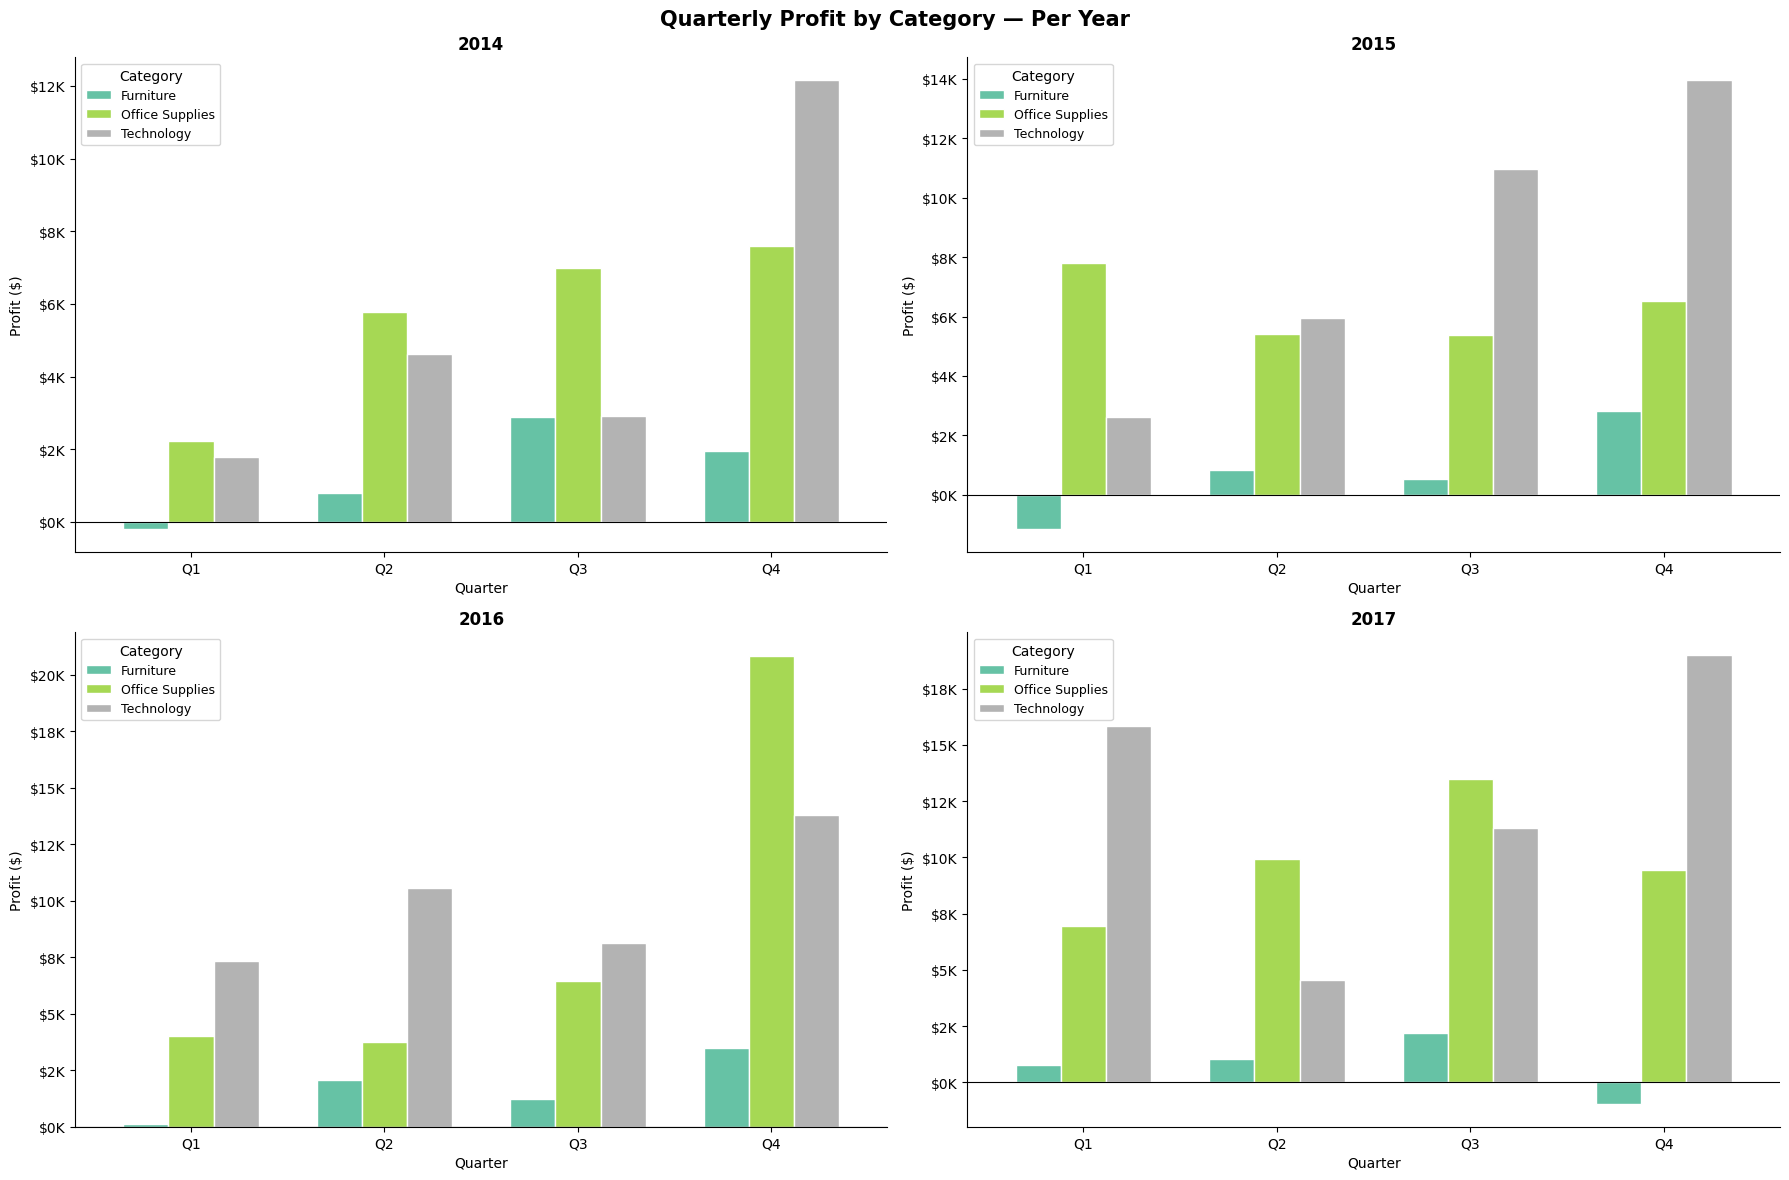

In [16]:
# Quarterly Profit by Category 
quarterly_profit = (store.groupby(['Order Year', 'Order Quarter', 'Category'])['Profit']
                    .sum()
                    .reset_index())

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Quarterly Profit by Category — Per Year', fontsize=15, fontweight='bold')

for idx, year in enumerate(sorted(quarterly_profit['Order Year'].unique())):
    ax = axes[idx // 2][idx % 2]
    data = quarterly_profit[quarterly_profit['Order Year'] == year]
    pivot = data.pivot(index='Order Quarter', columns='Category', values='Profit').fillna(0)

    pivot.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', width=0.7)

    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_title(f"{year}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Quarter')
    ax.set_ylabel('Profit ($)')
    ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'], rotation=0)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1000:.0f}K"))
    ax.legend(title='Category', fontsize=9)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

- Furniture is the least profitable category throughout, could suggest that although the sales are high - items are being sold at a highly discounted rate leading to low profitability.

In [17]:
# Overall Insights
print("\nINSIGHTS — Quarterly Category Analysis")
print("=" * 55)

best_category = (store.groupby('Category')['Profit'].sum().idxmax())
worst_category = (store.groupby('Category')['Profit'].sum().idxmin())
best_quarter = (store.groupby('Order Quarter')['Profit'].sum().idxmax())
worst_quarter = (store.groupby('Order Quarter')['Profit'].sum().idxmin())

print(f"  Most profitable category  : {best_category}")
print(f"  Least profitable category : {worst_category}")
print(f"  Strongest profit quarter  : Q{best_quarter}")
print(f"  Weakest profit quarter    : Q{worst_quarter}")


INSIGHTS — Quarterly Category Analysis
  Most profitable category  : Technology
  Least profitable category : Furniture
  Strongest profit quarter  : Q4
  Weakest profit quarter    : Q1


 FINDING #1 — The Q4 Furniture Trap
- Furniture generates the highest sales volume in Q4 but
operates at low profit margins. This suggests
aggressive discounting is being used to drive Q4 sales up. But it is at the expense of margin — this is consistent throughout all 4 years in the dataset.

FINDING #2 — Technology is the Silent Profit Engine
- Despite Q1 having the lowest overall sales, Technology consistently delivers the strongest profit contribution. This indicates Technology sells closer to full price and requires minimal discounting to generate demand.

STRATEGIC IMPLICATION
- Shifting Q4 marketing investment from Furniture promotions toward Technology upselling could maintain revenue while significantly improving overall margin.

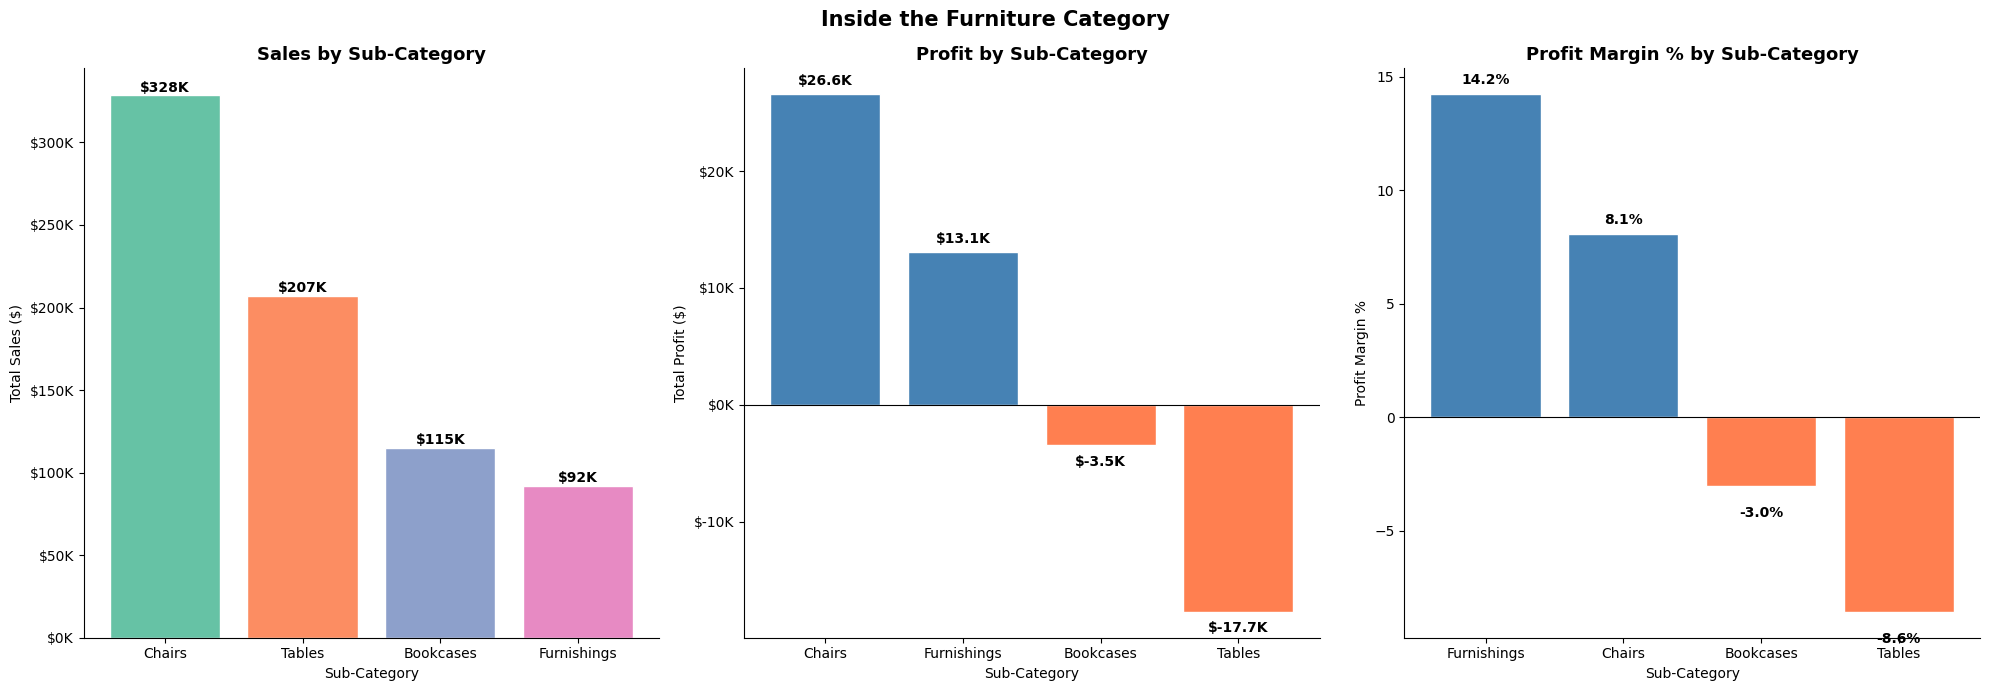

In [18]:
# Analysing Categories

furniture = store[store['Category'] == 'Furniture']

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Inside the Furniture Category', fontsize=15, fontweight='bold')

#  Graph 1: Sales by Sub-Category (Bar)
furniture_sales = (furniture.groupby('Sub-Category')['Sales']
                   .sum()
                   .sort_values(ascending=False)
                   .reset_index())

colors = sns.color_palette('Set2', len(furniture_sales))
bars = axes[0].bar(furniture_sales['Sub-Category'], furniture_sales['Sales'],
                   color=colors, edgecolor='white')

axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1000:.0f}K"))
axes[0].set_title('Sales by Sub-Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sub-Category')
axes[0].set_ylabel('Total Sales ($)')

for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 500,
                 f"${bar.get_height()/1000:.0f}K",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

sns.despine(ax=axes[0])

#  Graph 2: Profit by Sub-Category (Bar) 
furniture_profit = (furniture.groupby('Sub-Category')['Profit']
                    .sum()
                    .sort_values(ascending=False)
                    .reset_index())

colors2 = ['steelblue' if v >= 0 else 'coral'
           for v in furniture_profit['Profit']]
bars2 = axes[1].bar(furniture_profit['Sub-Category'], furniture_profit['Profit'],
                    color=colors2, edgecolor='white')

axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1000:.0f}K"))
axes[1].set_title('Profit by Sub-Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sub-Category')
axes[1].set_ylabel('Total Profit ($)')

for bar, val in zip(bars2, furniture_profit['Profit']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + (500 if val >= 0 else -2000),
                 f"${val/1000:.1f}K",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

sns.despine(ax=axes[1])

#  Graph 3: Profit Margin % by Sub-Category (Bar) 
furniture_margin = (furniture.groupby('Sub-Category')
                    .apply(lambda x: (x['Profit'].sum() / x['Sales'].sum()) * 100)
                    .reset_index(name='Profit Margin %')
                    .sort_values('Profit Margin %', ascending=False))

colors3 = ['steelblue' if v >= 0 else 'coral'
           for v in furniture_margin['Profit Margin %']]
bars3 = axes[2].bar(furniture_margin['Sub-Category'], furniture_margin['Profit Margin %'],
                    color=colors3, edgecolor='white')

axes[2].axhline(y=0, color='black', linewidth=0.8)
axes[2].set_title('Profit Margin % by Sub-Category', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Sub-Category')
axes[2].set_ylabel('Profit Margin %')

for bar, val in zip(bars3, furniture_margin['Profit Margin %']):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + (0.3 if val >= 0 else -1.5),
                 f"{val:.1f}%",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

sns.despine(ax=axes[2])

plt.tight_layout()
plt.show()


In [19]:
top_furniture_sales  = furniture_sales.iloc[0]['Sub-Category']
worst_furniture_profit = furniture_profit.iloc[-1]['Sub-Category']
worst_furniture_value    = furniture_profit.iloc[-1]['Profit']
worst_furniture_margin = furniture_margin.iloc[-1]['Sub-Category']
worst_margin_value       = furniture_margin.iloc[-1]['Profit Margin %']

print(f"  Highest selling sub-category  : {top_furniture_sales}")
print(f"  Most loss-making sub-category : {worst_furniture_profit} (${worst_furniture_value:,.0f})")
print(f"  Worst margin sub-category     : {worst_furniture_margin} ({worst_margin_value:.1f}%)")

  Highest selling sub-category  : Chairs
  Most loss-making sub-category : Tables ($-17,725)
  Worst margin sub-category     : Tables (-8.6%)
